In [17]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

In [18]:
df=pd.read_csv('smart_meter_data.csv')

In [19]:

# 2. Feature Engineering with Cyclical Encoding
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

# Combine Hour and Minute into a fractional hour (0.0 to 23.5) for precision
df['TimeOfDay'] = df['Timestamp'].dt.hour + (df['Timestamp'].dt.minute / 60.0)
df['DayOfWeek'] = df['Timestamp'].dt.dayofweek
df['Is_Weekend'] = df['DayOfWeek'].apply(lambda x: 1 if x >= 5 else 0)

# Apply Sine and Cosine Transformations
# Max cycle for TimeOfDay is 24 hours
df['Time_Sin'] = np.sin(2 * np.pi * df['TimeOfDay'] / 24)
df['Time_Cos'] = np.cos(2 * np.pi * df['TimeOfDay'] / 24)

# Max cycle for DayOfWeek is 7 days
df['Day_Sin'] = np.sin(2 * np.pi * df['DayOfWeek'] / 7)
df['Day_Cos'] = np.cos(2 * np.pi * df['DayOfWeek'] / 7)

# Create a feature capturing the actual spike or drop
df['Consumption_Deviation'] = df['Electricity_Consumed'] - df['Avg_Past_Consumption']

# Or capture it as a percentage spike
df['Consumption_Ratio'] = df['Electricity_Consumed'] / (df['Avg_Past_Consumption'] + 0.0001)
# Drop original linear time features
df = df.drop(columns=['Timestamp', 'TimeOfDay', 'DayOfWeek'])

# 3. Label Encoding
le = LabelEncoder()
df['Anomaly_Label'] = le.fit_transform(df['Anomaly_Label'])

# 4. Define Features (X) and Target (y)
X = df.drop(columns=['Anomaly_Label'])
y = df['Anomaly_Label']

# 5. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 6. Feature Scaling (Scaling continuous variables)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [23]:
from sklearn.ensemble import RandomForestClassifier, StackingClassifier, HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
import joblib
import shutil


# 1. Define Cost-Sensitive Base Models (Native Scikit-Learn only)
base_models = [
    ('rf', RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)),
    # HistGradientBoosting is Scikit-Learn's native equivalent to XGBoost
    ('hgb', HistGradientBoostingClassifier(class_weight='balanced', random_state=42))
]

# 2. Define a Cost-Sensitive Meta-Model
meta_model = LogisticRegression(class_weight='balanced')

# 3. Build and fit the Stacking Classifier
stacking_clf = StackingClassifier(
    estimators=base_models,
    final_estimator=meta_model,
    cv=5,
    n_jobs=-1
)

print("Training cross-platform safe model...")
stacking_clf.fit(X_train, y_train)

# 4. Save and Export
artifacts = {
    'model': stacking_clf,
    'scaler': scaler,
    'feature_names': list(X.columns),
    'anomaly_threshold': 0.5
}


Training cross-platform safe model...


c:\Users\RISHI\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=16.
  warnings.warn(
c:\Users\RISHI\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\RISHI\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but HistGradientBoostingClassifier was fitted with feature names
  warnings.warn(


  0%|          | 0/200 [00:00<?, ?it/s]

c:\Users\RISHI\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\RISHI\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but HistGradientBoostingClassifier was fitted with feature names
  warnings.warn(
c:\Users\RISHI\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\RISHI\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but HistGradientBoostingClassifier was fitted with feature names
  warnings.warn(
c:\Users\RISHI\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature na

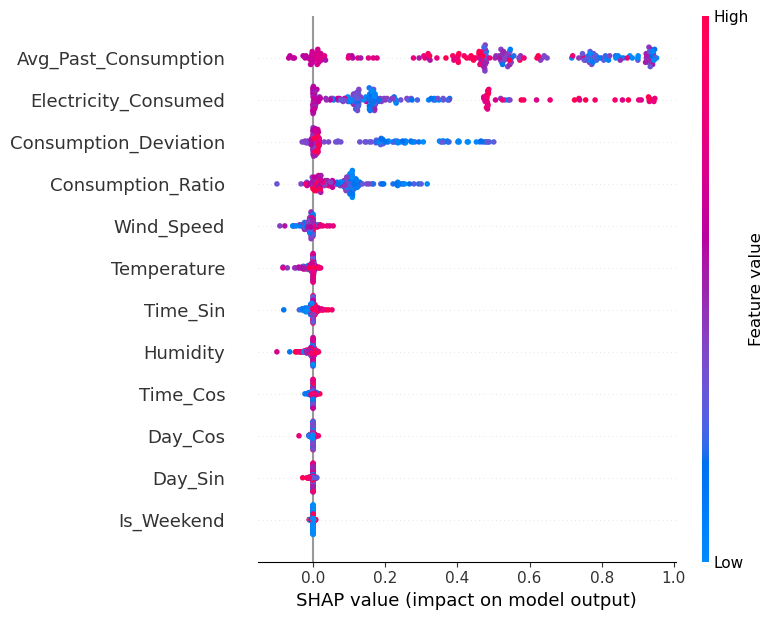

In [24]:
import shap

# 1. Create a probability wrapper function
# We want SHAP to explain what pushes the probability toward Class 0 (Anomaly)
def predict_anomaly_prob(X_data):
    # predict_proba returns a 2D array; column 0 is the probability of Class 0
    return stacking_clf.predict_proba(X_data)[:, 0]

# 2. Summarize the background dataset
# KernelExplainer uses background data to simulate "missing" features.
# K-Means reduces the training set down to 50 highly representative centroids.
background_summary = shap.kmeans(X_train, 50)

# 3. Initialize the Kernel Explainer
explainer = shap.KernelExplainer(predict_anomaly_prob, background_summary)

# 4. Calculate SHAP values for the test set
# We take a random sample of 200 test instances to evaluate.
# (Running KernelExplainer on thousands of rows is computationally expensive).
X_test_sample = X_test_scaled[:200]
shap_values = explainer.shap_values(X_test_sample)

# 5. Visualize the Global Feature Importance
# Ensure you pass the original feature names so the plot is readable
shap.summary_plot(shap_values, X_test_sample, feature_names=X.columns)

In [25]:
import joblib
import shutil


# Mount Drive


# Save using Protocol 4 (Compatible with all Python versions 3.4 and newer)
joblib.dump(
    artifacts, 
    'smart_meter_stacking_pipeline.joblib', 
    protocol=4  # This is the critical fix
)

['smart_meter_stacking_pipeline.joblib']